# Truncation Blind Spot: Model Complexity vs Detectability

**Models:** GPT-2, Qwen2, Llama 3.2, Mamba (SSM), RWKV (RNN)

**Datasets:** WikiText, News (CC-News)

**Decoding:** Top-p (p=0.95), Top-k (k=50)

In [ ]:
!pip install -q transformers accelerate bitsandbytes datasets scikit-learn pandas matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 33.3 MB/s eta 0:00:00


In [ ]:
import os, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, set_seed
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix

warnings.filterwarnings('ignore')
set_seed(42)

from google.colab import drive
drive.mount('/content/drive')

try:
    from google.colab import userdata
    from huggingface_hub import login
    login(token=userdata.get('HF_TOKEN'))
    print("HF authenticated")
except:
    print("HF auth skipped")

OUTPUT_DIR = '/content/drive/MyDrive/truncation_results'
for d in ['', '/figures', '/tables', '/data']:
    os.makedirs(f"{OUTPUT_DIR}{d}", exist_ok=True)

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Output: {OUTPUT_DIR}")

Mounted at /content/drive
HF authenticated
GPU: NVIDIA A100-SXM4-40GB
Memory: 42.5 GB
Output: /content/drive/MyDrive/truncation_results


In [ ]:
# Configuration
TOP_P = 0.95
TOP_K = 50
MAX_TOKENS = 200
NUM_SAMPLES = 150
TEST_SIZE = 0.2

MODELS = [
    # GPT-2 Family (Transformer)
    {"name": "GPT2-124M", "hf": "gpt2", "family": "GPT2", "arch": "transformer", "params": 124},
    {"name": "GPT2-355M", "hf": "gpt2-medium", "family": "GPT2", "arch": "transformer", "params": 355},
    {"name": "GPT2-774M", "hf": "gpt2-large", "family": "GPT2", "arch": "transformer", "params": 774},
    {"name": "GPT2-1.5B", "hf": "gpt2-xl", "family": "GPT2", "arch": "transformer", "params": 1500},
    # Qwen2 Family (Transformer)
    {"name": "Qwen2-0.5B", "hf": "Qwen/Qwen2-0.5B", "family": "Qwen2", "arch": "transformer", "params": 500},
    {"name": "Qwen2-1.5B", "hf": "Qwen/Qwen2-1.5B", "family": "Qwen2", "arch": "transformer", "params": 1500},
    {"name": "Qwen2-7B", "hf": "Qwen/Qwen2-7B", "family": "Qwen2", "arch": "transformer", "params": 7000, "quant": True},
    # Llama 3.2 Family (Transformer)
    {"name": "Llama3.2-1B", "hf": "meta-llama/Llama-3.2-1B", "family": "Llama", "arch": "transformer", "params": 1000},
    {"name": "Llama3.2-3B", "hf": "meta-llama/Llama-3.2-3B", "family": "Llama", "arch": "transformer", "params": 3000},
    # Mamba Family (SSM - Non-Transformer)
    {"name": "Mamba-130M", "hf": "state-spaces/mamba-130m-hf", "family": "Mamba", "arch": "ssm", "params": 130},
    {"name": "Mamba-370M", "hf": "state-spaces/mamba-370m-hf", "family": "Mamba", "arch": "ssm", "params": 370},
    {"name": "Mamba-790M", "hf": "state-spaces/mamba-790m-hf", "family": "Mamba", "arch": "ssm", "params": 790},
    {"name": "Mamba-1.4B", "hf": "state-spaces/mamba-1.4b-hf", "family": "Mamba", "arch": "ssm", "params": 1400},
    {"name": "Mamba-2.8B", "hf": "state-spaces/mamba-2.8b-hf", "family": "Mamba", "arch": "ssm", "params": 2800},
    # RWKV Family (RNN - Non-Transformer)
    {"name": "RWKV-169M", "hf": "RWKV/rwkv-4-169m-pile", "family": "RWKV", "arch": "rnn", "params": 169},
    {"name": "RWKV-430M", "hf": "RWKV/rwkv-4-430m-pile", "family": "RWKV", "arch": "rnn", "params": 430},
    {"name": "RWKV-1.5B", "hf": "RWKV/rwkv-4-1b5-pile", "family": "RWKV", "arch": "rnn", "params": 1500},
    {"name": "RWKV-3B", "hf": "RWKV/rwkv-4-3b-pile", "family": "RWKV", "arch": "rnn", "params": 3000},
]

print(f"Total models: {len(MODELS)}")
print(f"  Transformer: {len([m for m in MODELS if m['arch']=='transformer'])}")
print(f"  SSM (Mamba): {len([m for m in MODELS if m['arch']=='ssm'])}")
print(f"  RNN (RWKV): {len([m for m in MODELS if m['arch']=='rnn'])}")

Total models: 18
  Transformer: 9
  SSM (Mamba): 5
  RNN (RWKV): 4


In [ ]:
# Helper functions
def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def load_model(info):
    clear_gpu()
    print(f"  Loading {info['name']}...", end=" ", flush=True)
    try:
        tok = AutoTokenizer.from_pretrained(info["hf"], trust_remote_code=True)
        if tok.pad_token is None:
            tok.pad_token = tok.eos_token
        kw = {"device_map": "auto", "trust_remote_code": True}
        if info.get("quant"):
            kw["quantization_config"] = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_compute_dtype=torch.float16
            )
        else:
            kw["torch_dtype"] = torch.float16
        model = AutoModelForCausalLM.from_pretrained(info["hf"], **kw)
        model.eval()
        print(f"OK ({torch.cuda.memory_allocated()/1e9:.1f}GB)")
        return model, tok
    except Exception as e:
        print(f"FAILED: {e}")
        return None, None

def extract_samples(texts, tok, n):
    prompts, conts = [], []
    for t in texts:
        if len(prompts) >= n:
            break
        toks = tok.encode(t, add_special_tokens=False)
        if len(toks) < 50 + MAX_TOKENS:
            continue
        plen = np.random.randint(20, 51)
        p = tok.decode(toks[:plen], skip_special_tokens=True)
        c = tok.decode(toks[plen:plen+MAX_TOKENS], skip_special_tokens=True)
        if len(p.strip()) > 10 and len(c.strip()) > 30:
            prompts.append(p)
            conts.append(c)
    return prompts, conts

def generate(model, tok, prompts, strategy, bs=4):
    gen_kw = {"max_new_tokens": MAX_TOKENS, "do_sample": True, "pad_token_id": tok.pad_token_id}
    if strategy == 'top_p':
        gen_kw["top_p"] = TOP_P
        gen_kw["top_k"] = 0
    else:
        gen_kw["top_k"] = TOP_K
        gen_kw["top_p"] = 1.0
    out = []
    for i in range(0, len(prompts), bs):
        batch = prompts[i:i+bs]
        inp = tok(batch, return_tensors="pt", padding=True, truncation=True, max_length=50)
        inp = {k: v.to(model.device) for k, v in inp.items()}
        with torch.no_grad():
            o = model.generate(**inp, **gen_kw)
        for j, x in enumerate(o):
            plen = inp['input_ids'][j].shape[0]
            out.append(tok.decode(x[plen:], skip_special_tokens=True))
    return out

print("Helper functions defined")

Helper functions defined


In [ ]:
# Reference model and metrics
REF_MODEL = None
REF_TOK = None

def get_ref():
    global REF_MODEL, REF_TOK
    if REF_MODEL is None:
        print("  Loading reference model (OPT-1.3B)...")
        REF_TOK = AutoTokenizer.from_pretrained("facebook/opt-1.3b")
        REF_MODEL = AutoModelForCausalLM.from_pretrained(
            "facebook/opt-1.3b",
            torch_dtype=torch.float16,
            device_map="auto"
        )
        REF_MODEL.eval()
    return REF_MODEL, REF_TOK

def unload_ref():
    global REF_MODEL, REF_TOK
    if REF_MODEL is not None:
        del REF_MODEL, REF_TOK
        REF_MODEL = None
        REF_TOK = None
        clear_gpu()

def compute_pred(texts, prompts):
    model, tok = get_ref()
    preds = []
    for text, prompt in zip(texts, prompts):
        full = prompt + text
        inp = tok(full, return_tensors="pt", truncation=True, max_length=512)
        inp = {k: v.to(model.device) for k, v in inp.items()}
        plen = len(tok.encode(prompt, add_special_tokens=False))
        with torch.no_grad():
            logits = model(**inp).logits
        lp = F.log_softmax(logits[0, :-1], dim=-1)
        tlp = lp.gather(-1, inp['input_ids'][0, 1:].unsqueeze(-1)).squeeze(-1)
        if plen > 0 and tlp.shape[0] > plen - 1:
            tlp = tlp[plen-1:]
        preds.append(tlp.mean().item() if tlp.numel() > 0 else -10.0)
    return preds

def compute_div(texts):
    divs = []
    for t in texts:
        toks = t.split()
        if len(toks) < 4:
            divs.append(0.0)
            continue
        d = 1.0
        for n in [2, 3, 4]:
            ng = [tuple(toks[i:i+n]) for i in range(len(toks)-n+1)]
            if ng:
                d *= len(set(ng)) / len(ng)
        divs.append(d * 100)
    return divs

def train_clf(hf, mf):
    X = np.vstack([hf, mf])
    y = np.array([0]*len(hf) + [1]*len(mf))
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=-10.0)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=TEST_SIZE, random_state=42, stratify=y)
    sc = StandardScaler()
    Xtrs = sc.fit_transform(Xtr)
    Xtes = sc.transform(Xte)
    res = {}
    clfs = [
        ('NB', GaussianNB(), Xtr, Xte),
        ('LR', LogisticRegression(max_iter=1000), Xtrs, Xtes),
        ('RF', RandomForestClassifier(n_estimators=100, n_jobs=-1), Xtr, Xte)
    ]
    for nm, clf, xtr, xte in clfs:
        clf.fit(xtr, ytr)
        yp = clf.predict(xte)
        ypr = clf.predict_proba(xte)[:, 1]
        tn, fp, fn, tp = confusion_matrix(yte, yp).ravel()
        res[nm] = {
            'auc': roc_auc_score(yte, ypr),
            'f1': f1_score(yte, yp),
            'prec': precision_score(yte, yp),
            'rec': recall_score(yte, yp),
            'spec': tn/(tn+fp) if (tn+fp) > 0 else 0
        }
    return res

print("Metrics functions defined")

Metrics functions defined


In [ ]:
# Load datasets
ref_tok = AutoTokenizer.from_pretrained("gpt2")
ref_tok.pad_token = ref_tok.eos_token

PROMPTS = {}
HUMAN = {}

# 1. WikiText
print("Loading WikiText...")
ds = load_dataset("wikitext", "wikitext-103-raw-v1", split="test")
texts = [t['text'] for t in ds if len(t['text'].strip()) > 150]
PROMPTS['wikitext'], HUMAN['wikitext'] = extract_samples(texts, ref_tok, NUM_SAMPLES)
print(f"  WikiText: {len(PROMPTS['wikitext'])} samples")

# 2. News (CC-News)
print("Loading News (CC-News)...")
ds = load_dataset("cc_news", split="train", streaming=True)
texts = []
for item in ds:
    if len(texts) >= NUM_SAMPLES * 3:
        break
    t = item.get('text', '')
    if len(t) > 200:
        texts.append(t)
PROMPTS['news'], HUMAN['news'] = extract_samples(texts, ref_tok, NUM_SAMPLES)
print(f"  News: {len(PROMPTS['news'])} samples")

total = sum(len(v) for v in PROMPTS.values())
print(f"\nTotal: {total} prompts across {len(PROMPTS)} datasets")

Loading WikiText...


wikitext-103-raw-v1/test-00000-of-00001.(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-103-raw-v1/train-00000-of-00002(…):   0%|          | 0.00/157M [00:00<?, ?B/s]

wikitext-103-raw-v1/train-00001-of-00002(…):   0%|          | 0.00/157M [00:00<?, ?B/s]

wikitext-103-raw-v1/validation-00000-of-(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

  WikiText: 150 samples
Loading News (CC-News)...


README.md: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1117 > 1024). Running this sequence through the model will result in indexing errors


  News: 150 samples

Total: 300 prompts across 2 datasets


In [ ]:
# Main experiment loop
ALL_RESULTS = []
STRATEGIES = ['top_p', 'top_k']
FAILED_MODELS = []

print("=" * 70)
print(f"EXPERIMENT: {len(MODELS)} models x {len(STRATEGIES)} strategies x {len(PROMPTS)} datasets")
print("=" * 70)

for midx, minfo in enumerate(MODELS):
    print(f"\n[{midx+1}/{len(MODELS)}] {minfo['name']} ({minfo['params']}M) - {minfo['arch'].upper()}")

    model, tok = load_model(minfo)
    if model is None:
        FAILED_MODELS.append(minfo['name'])
        continue

    for dname in PROMPTS:
        dp = PROMPTS[dname]
        dh = HUMAN[dname]
        if not dp:
            continue

        for strat in STRATEGIES:
            print(f"  {dname}/{strat}...", end=" ", flush=True)
            try:
                gen = generate(model, tok, dp, strat)
                hp = compute_pred(dh, dp)
                hd = compute_div(dh)
                mp = compute_pred(gen, dp)
                md = compute_div(gen)
                hf = np.column_stack([hp, hd])
                mf = np.column_stack([mp, md])
                cr = train_clf(hf, mf)

                res = {
                    'model': minfo['name'],
                    'family': minfo['family'],
                    'arch': minfo['arch'],
                    'params': minfo['params'],
                    'dataset': dname,
                    'strategy': strat,
                    'h_pred': float(np.mean(hp)),
                    'h_div': float(np.mean(hd)),
                    'm_pred': float(np.mean(mp)),
                    'm_div': float(np.mean(md))
                }
                for cn, cm in cr.items():
                    for mn, mv in cm.items():
                        res[f"{cn}_{mn}"] = mv

                ALL_RESULTS.append(res)
                print(f"AUC={cr['RF']['auc']:.3f}")
            except Exception as e:
                print(f"ERROR: {e}")

    del model, tok
    clear_gpu()

    # Save intermediate results
    pd.DataFrame(ALL_RESULTS).to_csv(f"{OUTPUT_DIR}/data/intermediate.csv", index=False)

unload_ref()

DF = pd.DataFrame(ALL_RESULTS)
DF.to_csv(f"{OUTPUT_DIR}/data/final_results.csv", index=False)

print(f"\n{'=' * 70}")
print(f"COMPLETE: {len(ALL_RESULTS)} experiments")
if FAILED_MODELS:
    print(f"Failed models: {FAILED_MODELS}")
print("=" * 70)

EXPERIMENT: 18 models x 2 strategies x 2 datasets

[1/18] GPT2-124M (124M) - TRANSFORMER
  Loading GPT2-124M... 

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

OK (0.3GB)
  wikitext/top_p... 

...

pytorch_model-00005-of-00007.bin:   0%|          | 0.00/1.91G [00:00<?, ?B/s]

pytorch_model-00007-of-00007.bin:   0%|          | 0.00/515M [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

FAILED: Data processing error: CAS service error : IO Error: No space left on device (os error 28)


OSError: [Errno 28] No space left on device

In [ ]:
import os, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, set_seed
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix

warnings.filterwarnings('ignore')
set_seed(42)

from google.colab import drive
drive.mount('/content/drive')

# Run this in a new Colab cell to get your results
import pandas as pd
DF = pd.read_csv('/content/drive/MyDrive/truncation_results/data/intermediate.csv')
print(f"Recovered {len(DF)} experiments")
print(DF['model'].unique())

Mounted at /content/drive
Recovered 60 experiments
['GPT2-124M' 'GPT2-355M' 'GPT2-774M' 'GPT2-1.5B' 'Qwen2-0.5B' 'Qwen2-1.5B'
 'Qwen2-7B' 'Mamba-130M' 'Mamba-370M' 'Mamba-790M' 'Mamba-1.4B'
 'Mamba-2.8B' 'RWKV-169M' 'RWKV-430M' 'RWKV-1.5B']


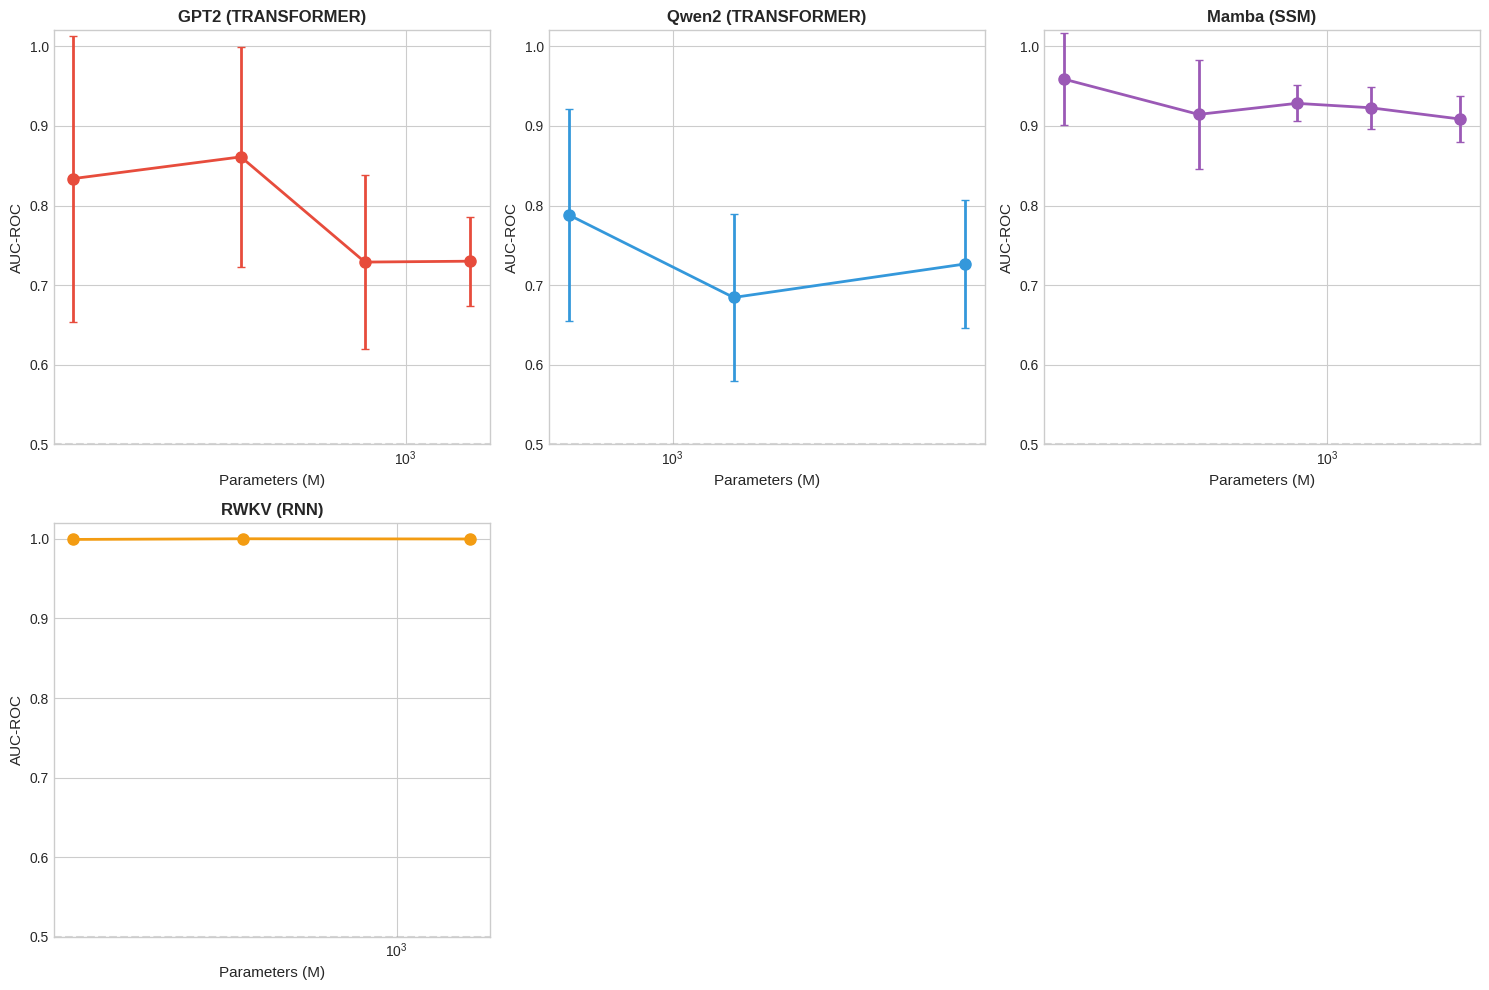

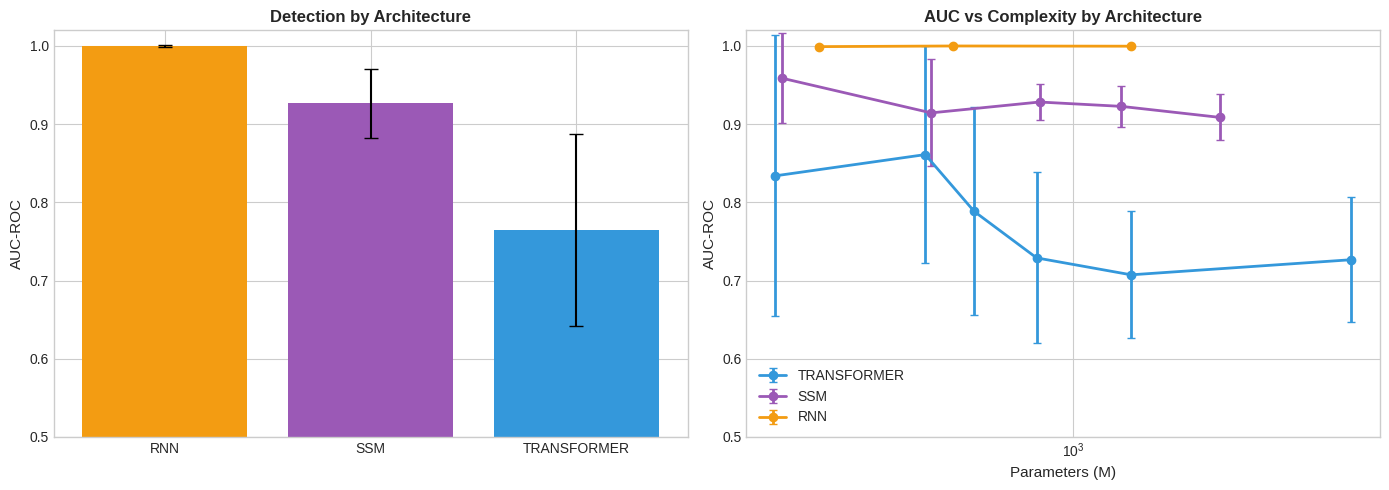

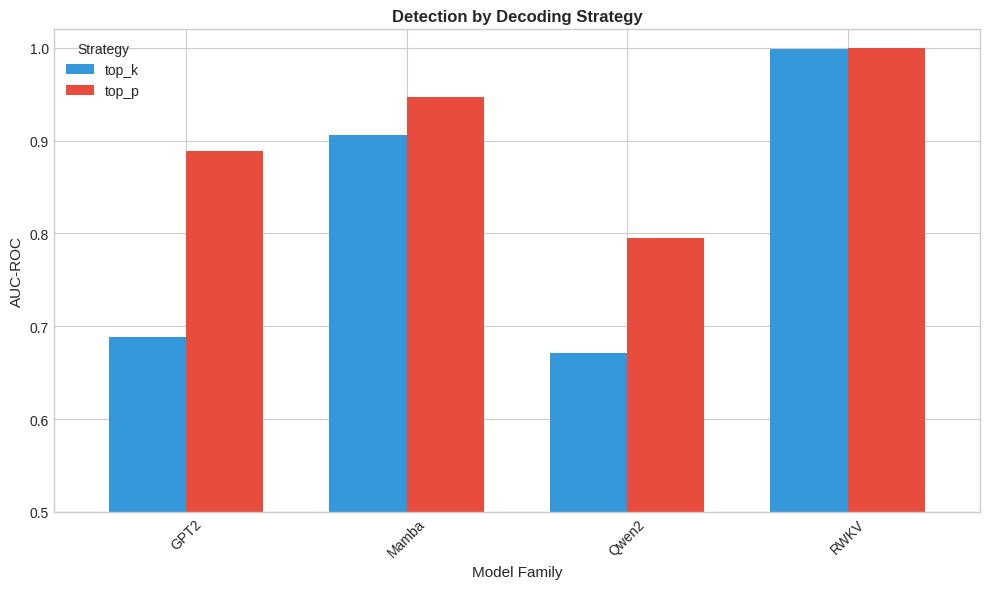

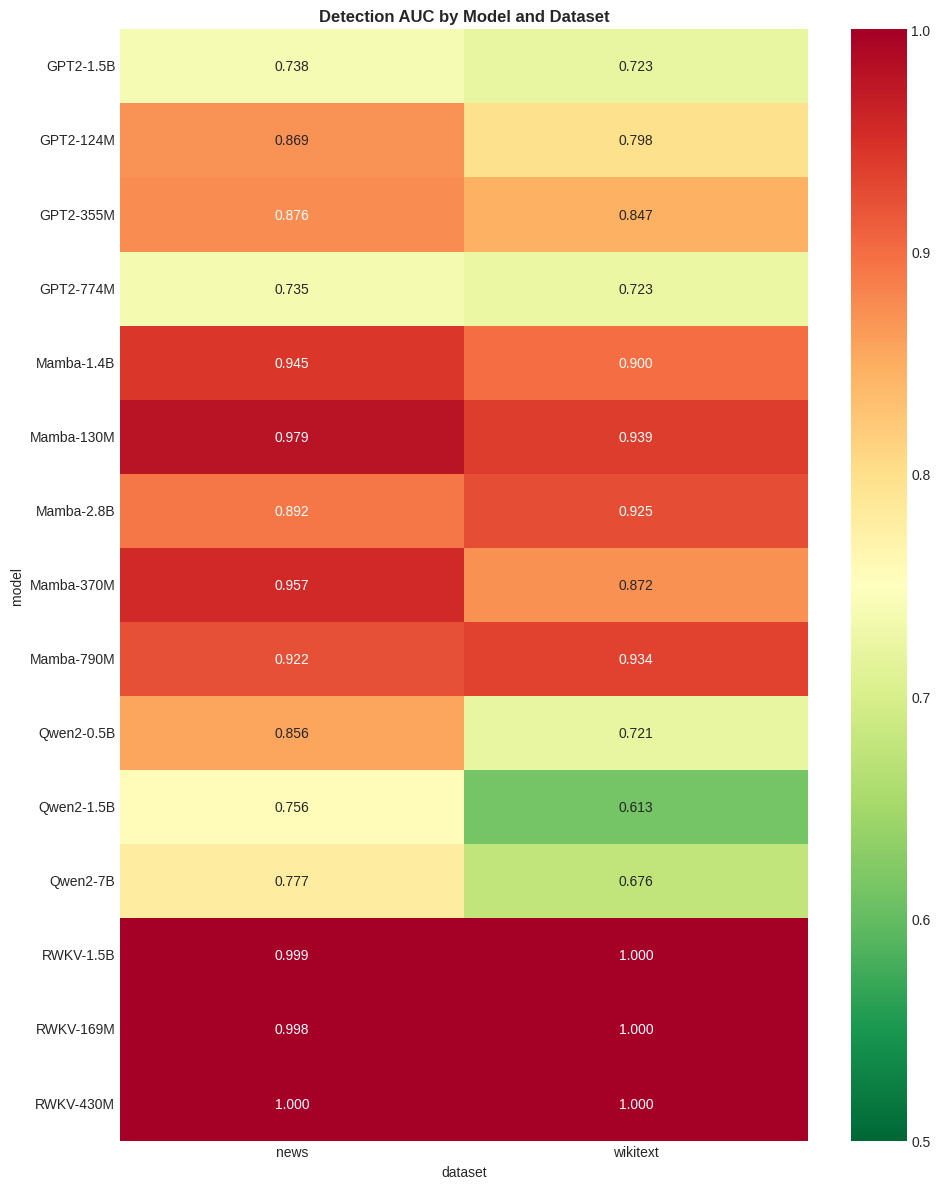

In [ ]:
OUTPUT_DIR = '/content/drive/MyDrive/truncation_results'

# Create figures
plt.style.use('seaborn-v0_8-whitegrid')
fam_colors = {'GPT2': '#E74C3C', 'Qwen2': '#3498DB', 'Llama': '#2ECC71', 'Mamba': '#9B59B6', 'RWKV': '#F39C12'}
arch_colors = {'transformer': '#3498DB', 'ssm': '#9B59B6', 'rnn': '#F39C12'}

# Figure 1: AUC vs Complexity by Family
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
families = DF['family'].unique()
for idx, fam in enumerate(families):
    if idx >= 6:
        break
    ax = axes.flatten()[idx]
    fd = DF[DF['family'] == fam]
    agg = fd.groupby('params').agg({'RF_auc': ['mean', 'std']}).reset_index()
    agg.columns = ['params', 'mean', 'std']
    agg = agg.sort_values('params')
    ax.errorbar(agg['params'], agg['mean'], yerr=agg['std'], marker='o', capsize=3,
                color=fam_colors.get(fam, 'gray'), linewidth=2, markersize=8)
    ax.set_xlabel('Parameters (M)', fontsize=11)
    ax.set_ylabel('AUC-ROC', fontsize=11)
    ax.set_title(f"{fam} ({fd['arch'].iloc[0].upper()})", fontsize=12, fontweight='bold')
    ax.set_ylim(0.5, 1.02)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3)
    ax.set_xscale('log')
for i in range(len(families), 6):
    axes.flatten()[i].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figures/fig1_auc_by_family.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{OUTPUT_DIR}/figures/fig1_auc_by_family.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Architecture comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
aa = DF.groupby('arch')['RF_auc'].agg(['mean', 'std']).reset_index()
bars = ax.bar(range(len(aa)), aa['mean'], yerr=aa['std'], capsize=5,
              color=[arch_colors.get(a, 'gray') for a in aa['arch']])
ax.set_xticks(range(len(aa)))
ax.set_xticklabels([a.upper() for a in aa['arch']])
ax.set_ylabel('AUC-ROC', fontsize=11)
ax.set_title('Detection by Architecture', fontsize=12, fontweight='bold')
ax.set_ylim(0.5, 1.02)

ax = axes[1]
for arch in DF['arch'].unique():
    ad = DF[DF['arch'] == arch]
    agg = ad.groupby('params')['RF_auc'].agg(['mean', 'std']).reset_index()
    agg = agg.sort_values('params')
    ax.errorbar(agg['params'], agg['mean'], yerr=agg['std'], marker='o',
                label=arch.upper(), capsize=3, color=arch_colors.get(arch, 'gray'), linewidth=2)
ax.set_xlabel('Parameters (M)', fontsize=11)
ax.set_ylabel('AUC-ROC', fontsize=11)
ax.set_title('AUC vs Complexity by Architecture', fontsize=12, fontweight='bold')
ax.set_xscale('log')
ax.set_ylim(0.5, 1.02)
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figures/fig2_architecture.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{OUTPUT_DIR}/figures/fig2_architecture.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: Strategy comparison
fig, ax = plt.subplots(figsize=(10, 6))
sp = DF.groupby(['family', 'strategy'])['RF_auc'].mean().reset_index()
sp = sp.pivot(index='family', columns='strategy', values='RF_auc')
sp.plot(kind='bar', ax=ax, width=0.7, color=['#3498DB', '#E74C3C'])
ax.set_ylabel('AUC-ROC', fontsize=11)
ax.set_xlabel('Model Family', fontsize=11)
ax.set_title('Detection by Decoding Strategy', fontsize=12, fontweight='bold')
ax.set_ylim(0.5, 1.02)
ax.legend(title='Strategy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figures/fig3_strategy.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{OUTPUT_DIR}/figures/fig3_strategy.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Figure 4: Heatmap
fig, ax = plt.subplots(figsize=(10, 12))
hm = DF.pivot_table(index='model', columns='dataset', values='RF_auc', aggfunc='mean')
sns.heatmap(hm, annot=True, fmt='.3f', cmap='RdYlGn_r', vmin=0.5, vmax=1.0, ax=ax)
ax.set_title('Detection AUC by Model and Dataset', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figures/fig4_heatmap.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{OUTPUT_DIR}/figures/fig4_heatmap.pdf", dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
# Create tables and summary
# Table 1: Results by model
t1 = DF.groupby(['model', 'family', 'arch', 'params']).agg({
    'RF_auc': ['mean', 'std'],
    'LR_auc': ['mean', 'std'],
    'NB_auc': ['mean', 'std'],
    'RF_spec': 'mean'
}).round(3)
t1.columns = ['RF_AUC', 'RF_std', 'LR_AUC', 'LR_std', 'NB_AUC', 'NB_std', 'Specificity']
t1 = t1.reset_index().sort_values(['arch', 'family', 'params'])
t1.to_csv(f"{OUTPUT_DIR}/tables/table1_by_model.csv", index=False)

# Table 2: Results by architecture
t2 = DF.groupby('arch').agg({
    'RF_auc': ['mean', 'std', 'min', 'max'],
    'LR_auc': ['mean', 'std'],
    'NB_auc': ['mean', 'std']
}).round(3)
t2.to_csv(f"{OUTPUT_DIR}/tables/table2_by_arch.csv")

# Table 3: Results by strategy
t3 = DF.groupby('strategy').agg({
    'RF_auc': ['mean', 'std'],
    'LR_auc': ['mean', 'std'],
    'NB_auc': ['mean', 'std']
}).round(3)
t3.to_csv(f"{OUTPUT_DIR}/tables/table3_by_strategy.csv")

# All results
DF.to_csv(f"{OUTPUT_DIR}/tables/all_results.csv", index=False)

# Print summary
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"\nOverall AUC: RF={DF['RF_auc'].mean():.3f} +/- {DF['RF_auc'].std():.3f}")
print(f"             LR={DF['LR_auc'].mean():.3f} +/- {DF['LR_auc'].std():.3f}")
print(f"             NB={DF['NB_auc'].mean():.3f} +/- {DF['NB_auc'].std():.3f}")

print(f"\nBy Architecture:")
for a in DF['arch'].unique():
    ad = DF[DF['arch'] == a]
    print(f"  {a.upper()}: {ad['RF_auc'].mean():.3f} +/- {ad['RF_auc'].std():.3f}")

print(f"\nBy Family:")
for f in DF['family'].unique():
    fd = DF[DF['family'] == f]
    print(f"  {f}: {fd['RF_auc'].mean():.3f} +/- {fd['RF_auc'].std():.3f}")

print(f"\nComplexity Effect (within-family):")
for f in DF['family'].unique():
    fd = DF[DF['family'] == f]
    agg = fd.groupby('params')['RF_auc'].mean().sort_index()
    if len(agg) > 1:
        change = agg.iloc[-1] - agg.iloc[0]
        print(f"  {f}: {change:+.3f} ({int(agg.index[0])}M -> {int(agg.index[-1])}M)")

print(f"\nBy Strategy:")
for s in DF['strategy'].unique():
    sd = DF[DF['strategy'] == s]
    print(f"  {s}: {sd['RF_auc'].mean():.3f} +/- {sd['RF_auc'].std():.3f}")

print("\n" + "=" * 70)
print("\nTABLE 1: Results by Model")
print("=" * 70)
print(t1.to_string(index=False))

print(f"\n\nAll results saved to {OUTPUT_DIR}")

SUMMARY

Overall AUC: RF=0.866 +/- 0.131
             LR=0.814 +/- 0.139
             NB=0.853 +/- 0.131

By Architecture:
  TRANSFORMER: 0.765 +/- 0.122
  SSM: 0.927 +/- 0.044
  RNN: 1.000 +/- 0.001

By Family:
  GPT2: 0.789 +/- 0.131
  Qwen2: 0.733 +/- 0.107
  Mamba: 0.927 +/- 0.044
  RWKV: 1.000 +/- 0.001

Complexity Effect (within-family):
  GPT2: -0.104 (124M -> 1500M)
  Qwen2: -0.062 (500M -> 7000M)
  Mamba: -0.050 (130M -> 2800M)
  RWKV: +0.001 (169M -> 1500M)

By Strategy:
  top_p: 0.912 +/- 0.100
  top_k: 0.820 +/- 0.144


TABLE 1: Results by Model
     model family        arch  params  RF_AUC  RF_std  LR_AUC  LR_std  NB_AUC  NB_std  Specificity
 RWKV-169M   RWKV         rnn     169   0.999   0.002   0.963   0.034   0.992   0.008        1.000
 RWKV-430M   RWKV         rnn     430   1.000   0.000   0.974   0.032   0.998   0.001        1.000
 RWKV-1.5B   RWKV         rnn    1500   1.000   0.001   0.953   0.030   0.997   0.003        1.000
Mamba-130M  Mamba         ssm     130   